## Data Ingestion

In [185]:
import pandas as pd
path_oct = "../data/raw/2019-Oct.csv"
path_nov = "../data/raw/2019-Nov.csv"
chunksize = 10 ** 6
chunks_oct = []
cols = ["event_time", "event_type", "user_id", "price"]
parse_dates = ["event_time"]
with pd.read_csv(path_oct, chunksize=chunksize, usecols=cols, parse_dates=parse_dates, dtype={'event_type' : 'category'}) as reader:
    for chunk in reader:
        chunks_oct.append(chunk)
        
df_oct = pd.concat(chunks_oct, ignore_index=True)
print(df_oct.head())

chunks_nov = []

with pd.read_csv(path_nov, chunksize=chunksize, usecols=cols, parse_dates=parse_dates, dtype={'event_type' : 'category'}) as reader:
    for chunk in reader:
        chunks_nov.append(chunk)
df_nov = pd.concat(chunks_nov, ignore_index=True)
print(df_nov.head())

                 event_time event_type    price    user_id
0 2019-10-01 00:00:00+00:00       view    35.79  541312140
1 2019-10-01 00:00:00+00:00       view    33.20  554748717
2 2019-10-01 00:00:01+00:00       view   543.10  519107250
3 2019-10-01 00:00:01+00:00       view   251.74  550050854
4 2019-10-01 00:00:04+00:00       view  1081.98  535871217
                 event_time event_type   price    user_id
0 2019-11-01 00:00:00+00:00       view  489.07  520088904
1 2019-11-01 00:00:00+00:00       view  293.65  530496790
2 2019-11-01 00:00:01+00:00       view   28.31  561587266
3 2019-11-01 00:00:01+00:00       view  712.87  518085591
4 2019-11-01 00:00:01+00:00       view  183.27  558856683


In [186]:
df_total = pd.concat([df_oct, df_nov], ignore_index=True)
df_total.tail()

,event_time,event_type,price,user_id
109950738,2019-11-30 23:59:58+00:00,view,277.74,532714000
109950739,2019-11-30 23:59:58+00:00,view,62.81,545223467
109950740,2019-11-30 23:59:59+00:00,view,167.03,557794415
109950741,2019-11-30 23:59:59+00:00,view,566.27,531607492
109950742,2019-11-30 23:59:59+00:00,view,1312.52,579969851


## Data Processing and Feature Engineering

In [187]:
df_total["week"] = df_total["event_time"].dt.isocalendar().week
df_total["weekday"] = df_total["event_time"].dt.dayofweek
print(df_total.head())

                 event_time event_type    price    user_id  week  weekday
0 2019-10-01 00:00:00+00:00       view    35.79  541312140    40        1
1 2019-10-01 00:00:00+00:00       view    33.20  554748717    40        1
2 2019-10-01 00:00:01+00:00       view   543.10  519107250    40        1
3 2019-10-01 00:00:01+00:00       view   251.74  550050854    40        1
4 2019-10-01 00:00:04+00:00       view  1081.98  535871217    40        1


In [188]:
print(df_total["price"].isna().sum())
print((df_total["price"] <= 0).sum())

0
256761


In [189]:
df_total = df_total[df_total["price"] > 0]
df_total.shape

(109693982, 6)

In [190]:
df_total["price_range"] = pd.qcut(q=3, labels=["Low", "Medium", "High"], x=df_total["price"])
df_total.head()

,event_time,event_type,price,user_id,week,weekday,price_range
0,2019-10-01 00:00:00+00:00,view,35.79,541312140,40,1,Low
1,2019-10-01 00:00:00+00:00,view,33.20,554748717,40,1,Low
2,2019-10-01 00:00:01+00:00,view,543.10,519107250,40,1,High
3,2019-10-01 00:00:01+00:00,view,251.74,550050854,40,1,Medium
4,2019-10-01 00:00:04+00:00,view,1081.98,535871217,40,1,High


In [191]:
df_total["price_range"].value_counts()

price_range
Medium    36571609
Low       36565711
High      36556662
Name: count, dtype: int64

## Funnel Analysis

### Naive Funnel Data Calculation

We will first calculate the funnel data for each stage with the assumption that users **must** go through the previous stage in order to go to the next one.

Then for example, a user has to view a product before placing it in their cart).

In [192]:
df_view = df_total[df_total["event_type"] == "view"]
unique_users_view = df_view["user_id"].nunique()
print(f"Number of unique users that viewed a product: {unique_users_view}")

df_cart = df_total[df_total["event_type"] == "cart"]
unique_users_cart = df_cart["user_id"].nunique()
print(f"Number of unique users that placed products after viewing in their cart: {unique_users_cart}")

df_purchase = df_total[df_total["event_type"] == "purchase"]
unique_users_purchase= df_purchase["user_id"].nunique()
print(f"Number of unique users that purchased a product in their carts: {unique_users_purchase}")

Number of unique users that viewed a product: 5314747
Number of unique users that placed products after viewing in their cart: 1053550
Number of unique users that purchased a product in their carts: 697470


### Strict Funnel Data Calculation

Now, we will calculate the funnel data in a progression-based manner. This means that we will only count the 
number of unique users in the cart stage using the unique users that were in the view stage. 

This will allow to check whether users could go straight into a latter stage without going through the previous one. 

In [193]:
df_view = df_total[df_total["event_type"] == "view"]
df_view_unique = df_view["user_id"].unique()
unique_users_view = len(df_view_unique)
print(f"Number of unique users that viewed a product: {unique_users_view}")

df_cart = df_total[df_total["event_type"] == "cart"]
df_cart_unique = df_cart.loc[df_cart["user_id"].isin(df_view_unique), "user_id"].unique()
unique_users_cart = len(df_cart_unique)
print(f"Number of unique users that placed products after viewing in their cart: {unique_users_cart}")

df_purchase = df_total[df_total["event_type"] == "purchase"]
df_purchase_unique = df_purchase.loc[df_purchase["user_id"].isin(df_cart_unique), "user_id"].unique()
unique_users_purchase = len(df_purchase_unique)
print(f"Number of unique users that purchased a product in their carts: {unique_users_purchase}")

Number of unique users that viewed a product: 5314747
Number of unique users that placed products after viewing in their cart: 1053178
Number of unique users that purchased a product in their carts: 565616


The results are as shown in the following table:

| Event | Naive | Strict |
|:--------:|:--------:|:--------:|
|  View   |  5314747   |  5314747  |
|  Cart   |  1053550   |  1053178   |
|  Purchase   |  697470   |  565616   |

This means that there are some users who directly placed a product in their cart without viewing it, and even more who purchased them directly without even placing them in their cart. 

Moving forward, we will use the strict progression-based data, as it is more accurate for a funnel analysis. 

In [194]:
cart_conversion_rate = (unique_users_cart / unique_users_view) * 100
print(f"Percentage of unique users that placed a product in their cart after viewing it: {round(cart_conversion_rate, 2)}%")

purchase_conversion_rate = (unique_users_purchase / unique_users_cart) * 100
print(f"Percentage of unique users that purchased a product after placing it in their cart: {round(purchase_conversion_rate, 2)}%")


Percentage of unique users that placed a product in their cart after viewing it: 19.82%
Percentage of unique users that purchased a product after placing it in their cart: 53.71%


### Funnel Analysis

In [195]:
import plotly.express as px
funnel_data = dict(
    number = [unique_users_view, unique_users_cart, unique_users_purchase],
    event = ["View", "Cart", "Purchase"]
)
df_funnel = pd.DataFrame(funnel_data)
df_funnel["prct"] = [100, round(cart_conversion_rate, 2), round(purchase_conversion_rate, 2)]
fig = px.funnel(df_funnel, x = "number", y = "event", title="E-Commerce Funnel Analysis", text="prct")
fig.update_traces(textposition='inside',texttemplate="%{x:.0f}<br>%{text:.2f}"+'%')
fig.show()

The funnel analysis shows that approximately 19.82% of users who view a product proceed to add it to their cart, while 53.71% of users who add a product to their cart complete a purchase. This indicates that the primary drop-off occurs in the early stage of the funnel, suggesting that product pages may not be sufficiently persuasive or that users are browsing without strong purchase intent. In contrast, the relatively high cart-to-purchase conversion suggests an efficient checkout process with low friction.

In [196]:
view_to_purchase = (unique_users_purchase / unique_users_view) * 100
print(f"Percentage of unique users who purchase a product after viewing it: {round(view_to_purchase, 2)}%")

Percentage of unique users who purchase a product after viewing it: 10.64%


Overall, around 10.64% of users who view a product end up making a purchase. This is a fairly standard-to-good conversion rate. 

### Funnel Analysis by Price Range

In this section, we will expand on the previous analysis, and perform funnel analysis by the price range of the products the users buy. This will allow us to understand whether there is a difference in conversion rates between products of different prices. 

In [197]:
segments = ["Low", "Medium", "High"]
df_funnel_price = pd.DataFrame()

price_segments = []

df_view = df_total[df_total["event_type"] == "view"]
df_cart = df_total[df_total["event_type"] == "cart"]
df_purchase = df_total[df_total["event_type"] == "purchase"]

for idx, segment in enumerate(segments):
    
    df_view_unique = df_view.loc[(df_view["price_range"] == segment), "user_id"].unique()
    views = len(df_view_unique)

    df_cart_unique = df_cart.loc[(df_cart["user_id"].isin(df_view_unique)) & (df_cart["price_range"] == segment), "user_id"].unique()
    carts = len(df_cart_unique)

    df_purchase_unique = df_purchase.loc[(df_purchase["user_id"].isin(df_cart_unique)) & (df_purchase["price_range"] == segment), "user_id"].unique()
    purchases = len(df_purchase_unique)
    
    price_segments.append([views, carts, purchases])
    
    

In [198]:
df_funnel_price = pd.DataFrame(price_segments)
df_funnel_price.head()

,0,1,2
0,3026585,389374,184313
1,3292068,506631,267518
2,3190543,436848,212343


In [199]:
df_funnel_price["price_range"] = ["Low", "Medium", "High"]
df_funnel_price = df_funnel_price.rename(columns = {0: "View", 1: "Cart", 2: "Purchase"})
df_funnel_price.head()

,View,Cart,Purchase,price_range
0,3026585,389374,184313,Low
1,3292068,506631,267518,Medium
2,3190543,436848,212343,High


In [200]:
df_funnel_price["View_Rates"] = [100, 100, 100]
df_funnel_price["Cart_Rates"] = round((df_funnel_price["Cart"] / df_funnel_price["View"]) * 100, 2)
df_funnel_price["Purchase_Rates"] = round((df_funnel_price["Purchase"] / df_funnel_price["Cart"]) * 100, 2)
df_funnel_price["Overall_Conversion_Rate"] = round((df_funnel_price["Purchase"] / df_funnel_price["View"]) * 100, 2)
df_funnel_price

,View,Cart,Purchase,price_range,View_Rates,Cart_Rates,Purchase_Rates,Overall_Conversion_Rate
0,3026585,389374,184313,Low,100,12.87,47.34,6.09
1,3292068,506631,267518,Medium,100,15.39,52.80,8.13
2,3190543,436848,212343,High,100,13.69,48.61,6.66


The results show that products in the medium price range showcase the strongest conversion rates across all stages, with an overall 8.13% compared to low and high priced products which sit around 6%. High priced products also show slightly higher rates than low priced products, with a 6.66% overall versus a 6.09% for low priced products. 

To visualize the results, we will use a grouped bar chart instead of a funnel chart. This will allow for a clearer comparison of their magnitudes and proportions. 

In [201]:
import plotly.graph_objects as go

fig = go.Figure(data=[
    go.Bar(name='View to Cart', x = df_funnel_price["price_range"], y = df_funnel_price["Cart_Rates"]),
    go.Bar(name='Cart to Purchase', x = df_funnel_price["price_range"], y = df_funnel_price["Purchase_Rates"]),
    go.Bar(name='View to Purchase', x = df_funnel_price["price_range"], y = df_funnel_price["Overall_Conversion_Rate"]),
])
fig.update_layout(barmode='group', title_text="Conversion Rates by Price Range",     
    xaxis={
        'title': {
            'text': 'Price Range'
        }
    },
    yaxis={
        'title': {
            'text': 'Conversion Rate (%)'
        }
    },)
fig.update_traces(textfont_size=12, textangle=0, textposition="outside", cliponaxis=False,
                texttemplate="%{y:.2f}"+'%')
fig.show()


The chart illustrates conversion rates across different price ranges, including view-to-cart, cart-to-purchase, and overall conversion. We can see that the view-to-cart conversion rates are not very high. However, once a customer places a product in their cart, they are likely to purchase it, with a likelihood of around 50% across all three price ranges. 

We can observe that the segmented funnel conversion rates are lower than the overall funnel rates calculated in the previous section. This is because users are required to complete all stages within the same price range. In turn, this means that someone who viewed a low priced product, and then placed a medium priced one and purchased it will not be counted here, while they would have in the overall funnel rates. Another highlight from this observation is that customers journeys are often not confined to a single price range.  

Overall, we can conclude that the main drop-off occurs in the view-to-cart process. Furthermore, price ranges do not appear to influence conversion rates signficantly, with a moderate increase in conversion rates in medium-priced products compared to the other two, and a slight increase in high-priced products versus lower-priced ones. 

## Cohort Analysis

We will perform a cohort analysis of the data. For an initial exploration, we will extract each user's first interaction (be it view, cart, or purchase), and the cohort will be the week where that interaction took place. 

In [202]:
df_total.head()

,event_time,event_type,price,user_id,week,weekday,price_range
0,2019-10-01 00:00:00+00:00,view,35.79,541312140,40,1,Low
1,2019-10-01 00:00:00+00:00,view,33.20,554748717,40,1,Low
2,2019-10-01 00:00:01+00:00,view,543.10,519107250,40,1,High
3,2019-10-01 00:00:01+00:00,view,251.74,550050854,40,1,Medium
4,2019-10-01 00:00:04+00:00,view,1081.98,535871217,40,1,High


In [203]:
weeks = df_total["week"].unique()
weeks

<IntegerArray>
[40, 41, 42, 43, 44, 45, 46, 47, 48]
Length: 9, dtype: UInt32

In [233]:

df_total["first_week"] = df_total.groupby("user_id")["week"].transform("min")
    
cohort = df_total.groupby(["first_week", "week"])["user_id"].nunique().reset_index()
cohort.columns = ["first_week", "week", "users"]
    
cohort["period"] = cohort["week"] - cohort["first_week"]
    
cohort_pivot = cohort.pivot_table(index="first_week", columns="period", values="users")
cohort_pctg = cohort_pivot.div(cohort_pivot[0], axis=0)

The missing values represent periods that are not observable for each given cohort. 

We will use a seaborn heatmap to visualize the cohort analysis. 

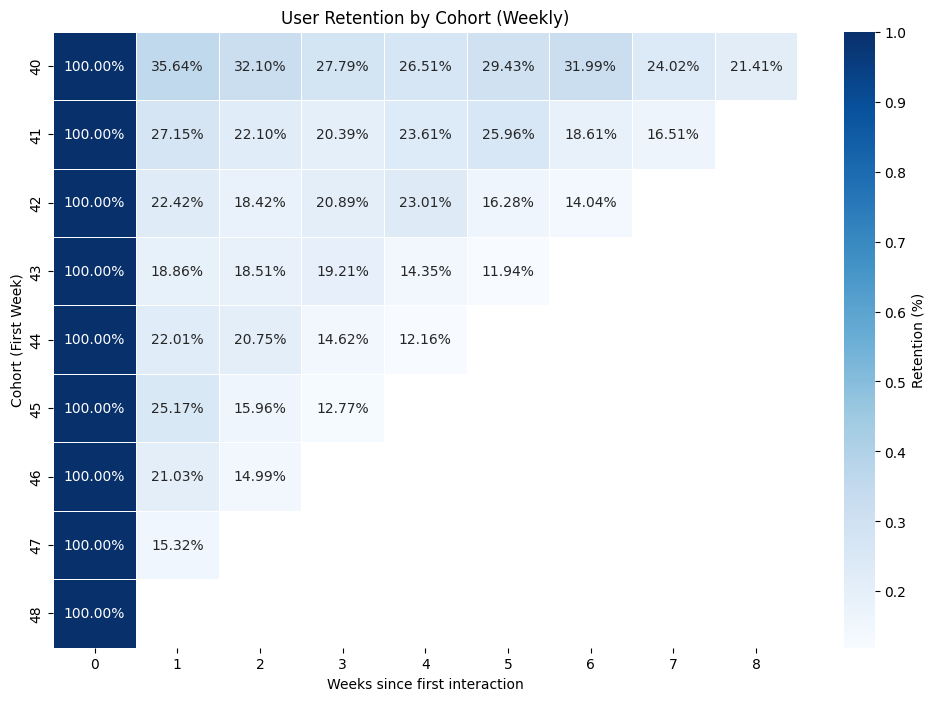

In [234]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(cohort_pctg, annot=True, fmt=".2%", cmap="Blues", linewidths=0.5,
            linecolor='white', cbar_kws={'label': 'Retention (%)'})

plt.title("User Retention by Cohort (Weekly)")
plt.xlabel("Weeks since first interaction")
plt.ylabel("Cohort (First Week)")
plt.show()

The cohort analysis reveals a significant drop in retention after the first week across all cohorts, indicating that a large proportion of users do not return after their initial interaction. The first cohort exhibits slightly higher early retention (~35%) compared to subsequent cohorts (15–27%), which may be due to differences in data coverage or user behavior. After the initial drop, retention stabilizes across all cohorts, indicating the presence of a core group of users who remain consistently active over time. 

These results indicate that improving early user engagement could significantly increase overall retention. At the same time, the relatively stable retention observed after the first week suggests that existing mechanisms for retaining engaged users are already effective.